# Módulo de Matemáticas 101: práctica

Vamos a poner de nuevo en práctica lo que hemos visto en este módulo. La práctica se centra en la regresión lineal (¡tema muy importante!) y podéis preguntarme las dudas que tengáis por Discord. ¡Mucha suerte!

## 1. Regresión lineal con mínimos cuadrados

En este ejercicio vamos a implementar la forma matricial de la regresión lineal con el método de los mínimos cuadrados. Para ello, tendrás que:

- Explorar un dataset
- Implementar la regresión lineal
- Aplicarla a un dataset concreto

Como recordatorio, los valores de los pesos $\widehat{w}$ vienen dados por:

<center>$\widehat{w} = (X^T X)^{-1}X^T y,$</center>

Donde $y$ es la variable a predecir y $X$ la matriz de features (NOTA: revisa cómo se define en los apuntes). Sabemos que los pesos van a ser los parámetros de la ecuación lineal que estamos intentando ajustar y tendremos uno por cada variable de entrada que usemos y además un término independiente o bias.

### 1.1 Carga del dataset y exploración de datos

Vamos a usar el dataset de [Auto MPG](https://archive.ics.uci.edu/dataset/9/auto+mpg) que podemos encontrar en el [repositorio de Machine learning de UC Irvine](https://archive.ics.uci.edu/). Lo primero, vamos a familiarizarnos con los datos.

En el propio repositorio nos indican cómo descargar el dataset con su librería (podemos consultar el código fuente si queremos).

In [1]:
pip install ucimlrepo

Defaulting to user installation because normal site-packages is not writeable
  Using cached ucimlrepo-0.0.7-py3-none-any.whl.metadata (5.5 kB)
Using cached ucimlrepo-0.0.7-py3-none-any.whl (8.0 kB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: C:\Users\PREDATOR\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [30]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
auto_mpg = fetch_ucirepo(id=9) 
  
# data (as pandas dataframes) 
X = auto_mpg.data.features 
y = auto_mpg.data.targets 
  
# metadata 
print(auto_mpg.metadata) 
  
# variable information 
print(auto_mpg.variables) 


{'uci_id': 9, 'name': 'Auto MPG', 'repository_url': 'https://archive.ics.uci.edu/dataset/9/auto+mpg', 'data_url': 'https://archive.ics.uci.edu/static/public/9/data.csv', 'abstract': 'Revised from CMU StatLib library, data concerns city-cycle fuel consumption', 'area': 'Other', 'tasks': ['Regression'], 'characteristics': ['Multivariate'], 'num_instances': 398, 'num_features': 7, 'feature_types': ['Real', 'Categorical', 'Integer'], 'demographics': [], 'target_col': ['mpg'], 'index_col': ['car_name'], 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 1993, 'last_updated': 'Thu Aug 10 2023', 'dataset_doi': '10.24432/C5859H', 'creators': ['R. Quinlan'], 'intro_paper': None, 'additional_info': {'summary': 'This dataset is a slightly modified version of the dataset provided in the StatLib library.  In line with the use by Ross Quinlan (1993) in predicting the attribute "mpg", 8 of the original instances were removed because they had unknown values for th

Con la función `head` de Pandas podemos ver las primeras filas del dataset.

In [31]:
X.head()

,displacement,cylinders,horsepower,weight,acceleration,model_year,origin
0,307.0,8,130.0,3504,12.0,70,1
1,350.0,8,165.0,3693,11.5,70,1
2,318.0,8,150.0,3436,11.0,70,1
3,304.0,8,150.0,3433,12.0,70,1
4,302.0,8,140.0,3449,10.5,70,1


In [32]:
y.head()

,mpg
0,18.0
1,15.0
2,18.0
3,16.0
4,17.0


En este punto, puedes hacer cualquier otro análisis exploratorio que creas conveniente.

A continuación, crea una función a la que le pases los dataframes de features y de target y el nombre de la variable y haga la gráfica del target (consumo en millas por galón) vs la variable que le ha llegado por parámetro. Puedes ver un ejemplo de gráfica más abajo, pero usa los parámetros que quieras en cuanto a color de los puntos, grids etc.

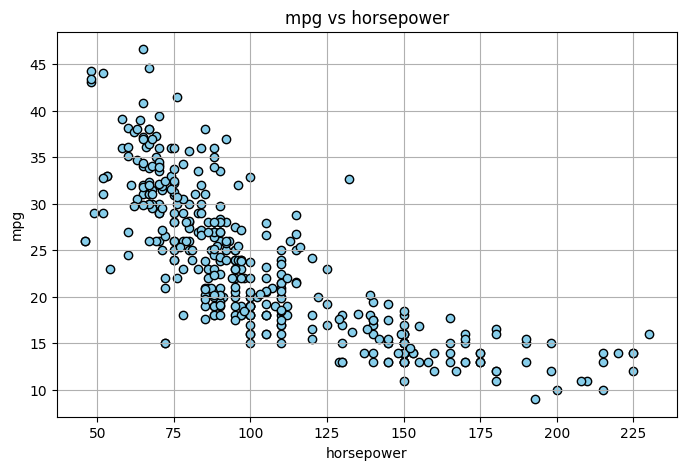

In [65]:
import matplotlib.pyplot as plt

def visualiza(X, y, variable):
   
    plt.figure(figsize=(8, 5))
    plt.scatter(X[variable], y, color='skyblue', edgecolor='black')
    plt.xlabel(variable)
    plt.ylabel('mpg')
    plt.title(f'mpg vs {variable}')
    plt.grid(True)
    plt.show()

# Ejemplo de uso:
visualiza(X, y, 'horsepower')

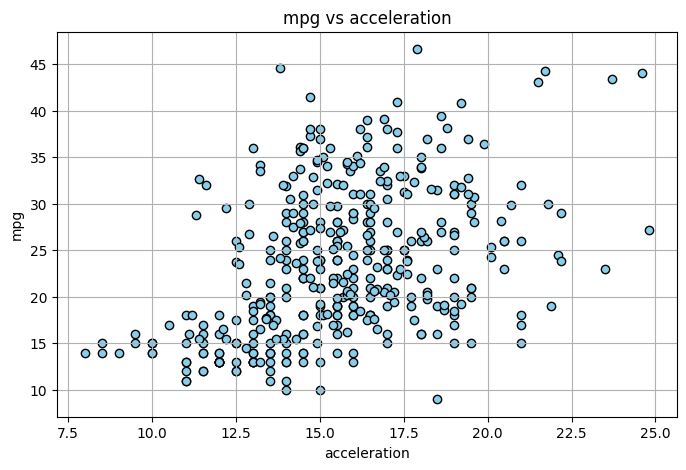

In [66]:
visualiza(X, y, 'acceleration')

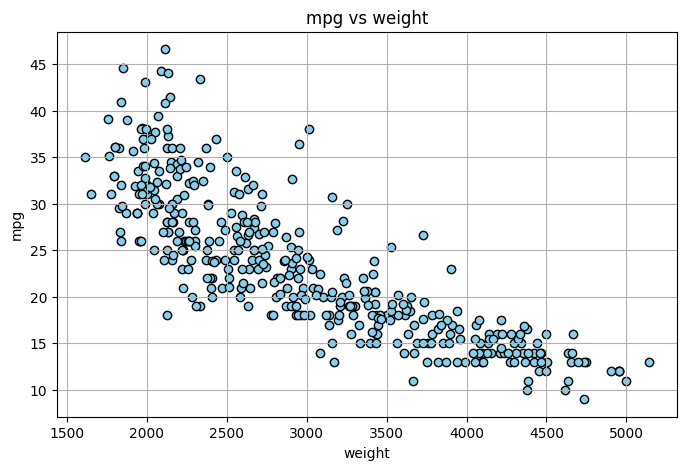

In [67]:
visualiza(X, y, 'weight')

IMPORTANTE: Aunque lo ideal sería un modelo multivariante, vamos a elegir la variable `weight` y hacer una regresión lineal solo con esta variable.

### 1.2 Implementación del modelo

En este punto vamos a dar un paso atrás y olvidarnos de los datos de consumo por un momento, porque el algoritmo que vamos a implementar serviría para cualquier conjunto de datos.

Lo primero, implementa una función que devuelva los valores de $\widehat{w}$ dados X e y. Si se da el caso de que el dataset tiene más features que observaciones, queremos transponerlo antes de realizar las operaciones. Lo hacemos porque, como vimos en clase, los resultados no van a ser buenos si el número de observaciones es menor.

In [68]:
import numpy as np

def pesos_ols(X, y):
    # Aseguramos que y sea columna
    if y.ndim == 1:
        y = y.reshape(-1, 1)

    # Transponemos si hay más features que observaciones
    if X.shape[0] < X.shape[1]:
        X = X.T

    # Añadimos columna de unos (intercepto)
    ones = np.ones((X.shape[0], 1))
    X_b = np.hstack((ones, X))  # X con bias/intercepto

    # Aplicamos la fórmula matricial de OLS
    XtX_inv = np.linalg.inv(X_b.T @ X_b)
    XtY = X_b.T @ y
    w = XtX_inv @ XtY

    return w

In [69]:
# Array de prueba!!
X = np.array([[1710, 1262, 1786, 1717, 2198, 1362, 1694, 2090, 1774, 1077], 
              [2003, 1976, 2001, 1915, 2000, 1993, 2004, 1973, 1931, 1939]])
y = np.array([208500, 181500, 223500, 140000, 250000, 143000, 307000, 200000, 129900, 118000])
pesos_ols(X, y)

array([[-2.29223802e+06],
       [ 5.92536529e+01],
       [ 1.20780450e+03]])

Hemos implementado el algoritmo de mínimos cuadrados y lo hemos probado en un array de tamaño 2x10. Como pista, el resultado que he obtenido para este array de prueba es el siguiente:

array([-2.29223802e+06,  5.92536529e+01,  1.20780450e+03])

### 1.3 Prueba del modelo en los datos de consumo de coches

Ya podemos usar nuestra función `pesos` en el dataset real que hemos descargado, el de consumo de combustible. Para ver el ajuste, dibuja de nuevo los datos junto con la recta que has obtenido, en la misma gráfica. Tendrás que convertir los dataframes de Pandas en arrays de numpy para poder aplicar las operaciones matriciales.

TIP: Revisa las dimensiones de todos los arrays para ver que son correctas.

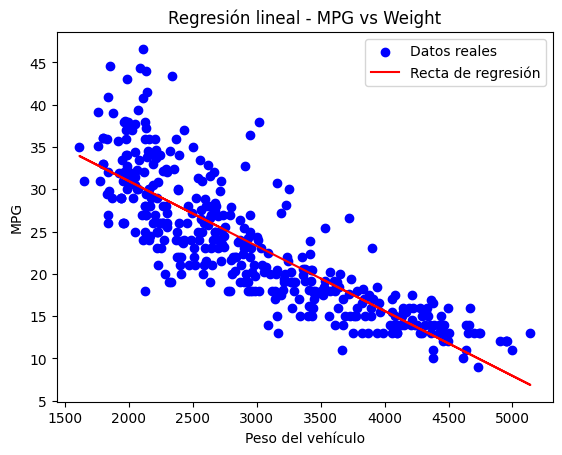

Término independiente (bias): 46.317364420265655
Pendiente: -0.007676610063926457


In [78]:
# TODO Aplica el modelo y dibuja la recta junto con los datos
import numpy as np
import matplotlib.pyplot as plt
from ucimlrepo import fetch_ucirepo

# 1. Cargado el dataset
auto_mpg = fetch_ucirepo(id=9)
X_full = auto_mpg.data.features
y_full = auto_mpg.data.targets

# 2. Ahora se filtran solo columnas necesarias
df = X_full.join(y_full)
df = df[['weight', 'mpg']].dropna()

# 3. Extrayendo 'X' y 'y' como arrays numpy
X = df['weight'].values.reshape(-1, 1)
y = df['mpg'].values.reshape(-1, 1)

# 4. añadiendo columna de 1s para el término independiente
X_bias = np.hstack([np.ones_like(X), X])

# 5. cálculo de los pesos con la fórmula de mínimos cuadrados
# w = (XᵗX)^-1 Xᵗy
XtX_inv = np.linalg.inv(X_bias.T @ X_bias)
w = XtX_inv @ X_bias.T @ y

# 6. predicciones
y_pred = X_bias @ w

# 7. Grafico
plt.scatter(X, y, color='blue', label='Datos reales')
plt.plot(X, y_pred, color='red', label='Recta de regresión')
plt.xlabel('Peso del vehículo')
plt.ylabel('MPG')
plt.title('Regresión lineal - MPG vs Weight')
plt.legend()
plt.show()

# Mostrando pesos
print("Término independiente (bias):", w[0][0])
print("Pendiente:", w[1][0])

Por último, vamos a comparar el resultado con el que nos da `scikit-learn`para ver si nuestra implementación tiene buena pinta. Podemos ver cómo funciona en la [documentación](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html).

In [71]:
!pip install scikit-learn


[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [72]:
!{sys.executable} -m pip install scikit-learn

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: C:\Users\PREDATOR\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [80]:
from sklearn.linear_model import LinearRegression

# Creamos el objeto
lr = LinearRegression()

# paso los datos
X = auto_mpg.data.features 
y = auto_mpg.data.targets 

X_lr = X[['weight']]
y_lr = y

# Entrenamos con los datos
lr.fit(X_lr,y_lr)
print("Punto de corte:", lr.intercept_)
print("Pendiente:", lr.coef_)

Punto de corte: [46.31736442]
Pendiente: [[-0.00767661]]


**TODO**: Analiza el resultado obtenido y compáralo con el de sklearn
### Comparación entre OLS y scikit-learn
Cuando comparamos los coeficientes obtenidos usando la fórmula de los mínimos cuadrados con los de `scikit-learn` vemos que son prácticamente iguales:
Intercepto ≈ 46.32
Pendiente ≈ -0.00768

Entonces quiere decir que la implementación es correcta y ajusta lo suficientela recta de regresión.

### 1.4 Compara el método de mínimos cuadrados y el descenso del gradiente para obtener los coeficientes de una regresión lineal



Coeficientes aprendidos:
Intercepto (bias): 23.5145728643216
Pendiente: -6.492702022678117


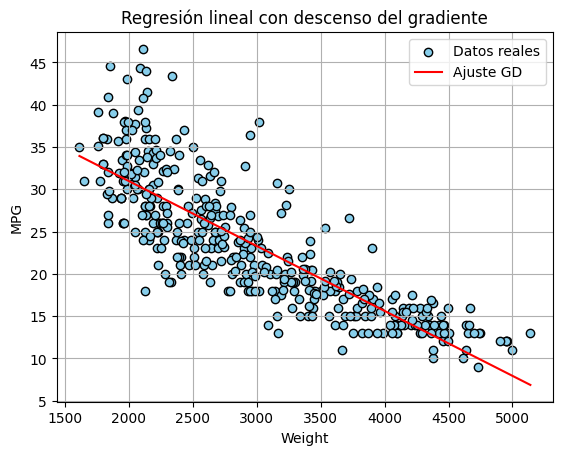

In [81]:
import numpy as np
import matplotlib.pyplot as plt

# Extrayendo las variables 'X' y 'y'
X = auto_mpg.data.features[['weight']].values  # (n, 1)
y = auto_mpg.data.targets.values.reshape(-1, 1)  # (n, 1)

# Normalizando los datos
X_mean = X.mean()
X_std = X.std()
X_norm = (X - X_mean) / X_std

# añadiendo columna de 1s para el término independiente (bias)
X_b = np.hstack([np.ones((X.shape[0], 1)), X_norm])  # (n, 2)

# pesos
w = np.random.randn(2, 1)  # [bias, coeficiente]

# Hiperparámetros
learning_rate = 0.1
n_iter = 1000
m = X_b.shape[0]  # número de observaciones

loss_history = []

# Descenso del gradiente
for iteration in range(n_iter):
    gradients = (2/m) * X_b.T @ (X_b @ w - y)
    w = w - learning_rate * gradients

    # Error cuadrático medio (MSE)
    loss = np.mean((X_b @ w - y)**2)
    loss_history.append(loss)

print("Coeficientes aprendidos:")
print("Intercepto (bias):", w[0][0])
print("Pendiente:", w[1][0])

# grafico del ajuste
plt.scatter(X, y, color='skyblue', edgecolor='black', label='Datos reales')
X_plot = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
X_plot_norm = (X_plot - X_mean) / X_std
X_plot_b = np.hstack([np.ones((X_plot.shape[0], 1)), X_plot_norm])
y_pred_plot = X_plot_b @ w

plt.plot(X_plot, y_pred_plot, color='red', label='Ajuste GD')
plt.xlabel('Weight')
plt.ylabel('MPG')
plt.title('Regresión lineal con descenso del gradiente')
plt.legend()
plt.grid(True)
plt.show()

## 2. Optimización con descenso del gradiente

Vamos a resolver el mismo problema usando el descenso del gradiente en lugar de la solución analítica. El descenso del gradiente es un método de optimización iterativo que usa el operador gradiente.

Como es iterativo, necesitamos decirle cuándo tiene que parar y darnos la solución. En este caso, le vamos a decir que pare y nos devuelva la solución después de un número de iteraciones que le pasaremos como parámetro. La ecuación iterativa es.

$$w^{t+1} = w^t - \eta \cdot \nabla f(w)$$

donde f es nuestra función objetivo, y w es un vector. Para la función objetivo, vamos a usar el error RSS, que querremos minimizar.

$$ RSS(w) = \frac{1}{2}\sum_{n=1}^{N}[y_n-f(x_n)]^2$$

y cuyo gradiente es:

$$\nabla RSS(w) = X^T(Xw^t-y)$$

TIP: Ten en cuenta que el RSS también lo puedes escribir como $\frac{1}{2}\sum_{n=1}^{N}[y_n-\hat{y_n}]^2$ donde $\hat{y_n} = X \hat{w}$ en cada paso.

### 2.1 Implementar el descenso del gradiente

Completa las siguientes funciones para implementar el descenso del gradiente con la función objetivo de la regresión lineal. La función necesitará:

- La entrada X y salida y de la regresión
- Un punto inicial desde el que empezar a iterar
- El número de iteraciones 
- El learning rate

La función nos devolverá un array con las w resultantes de las iteraciones y otro con el valor de la función en cada paso del algoritmo, a la que también se conoce como *loss function*.

In [82]:
import numpy as np

def rss(X, y, w):
    y_pred = X @ w
    return 0.5 * np.sum((y - y_pred) ** 2)

def gradient_descent(X, y, w0, n_iter, eta): 
    X_b = X  # <- X ya debe tener la columna de 1s incluida
    
    loss_iter = []
    w_iter = []
    w = w0.copy()
    
    for _ in range(n_iter):
        gradient = X_b.T @ (X_b @ w - y)
        w = w - eta * gradient / len(X)
        w_iter.append(w.copy())
        loss_iter.append(rss(X_b, y, w))
    
    return np.array(w_iter), np.array(loss_iter)

# Parámetros
eta = 0.01 
iteraciones = 2000 

np.random.seed(123)
w0 = np.random.rand(2).reshape((2,1))  # Vector de pesos inicial (2x1)

# Datos (X ya está normalizado)
y = np.array([208500, 181500, 223500, 140000, 250000]).reshape((5,1))
X = np.array([[  0.37020659],
              [ -0.48234664],
              [  0.51483616],
              [  0.38352774],
              [  1.29888065]])

# Agregando columna de 1s (bias)
X_b = np.hstack([np.ones((X.shape[0], 1)), X])

# Ejecutando descenso del gradiente
weights, loss = gradient_descent(X_b, y, w0, iteraciones, eta)

# Mostrando el último vector de pesos aprendido
print("Pesos finales:")
print(weights[-1])

Pesos finales:
[[183695.36963666]
 [ 40682.97678324]]


### 2.2 Aplicar al dataset de consumo de combustible

Leemos de nuevo los datos y aplicamos la función que acabamos de programar.

In [84]:
import numpy as np
from ucimlrepo import fetch_ucirepo 

# 1 cargando dataset
auto_mpg = fetch_ucirepo(id=9) 
X = auto_mpg.data.features 
y = auto_mpg.data.targets 

# 2 Convirtinedo columnas específicas a numpy
X_np = X['weight'].to_numpy().reshape((X.shape[0], 1))
y_np = y.to_numpy()

# 3. Normalización de X
X_mean = X_np.mean()
X_std = X_np.std()
X_np_norm = (X_np - X_mean) / X_std

# 4. Añadiendo columna de unos
X_np_ones = np.hstack([np.ones_like(X_np_norm), X_np_norm])

# 5. Asegurando que y_np tenga forma (n,1)
y_np = y_np.reshape((-1, 1))

# 6. Inicializar parámetros
np.random.seed(0)
w0 = np.random.rand(2, 1)
eta = 0.01
iteraciones = 3000

# 7. Ejecutando descenso del gradiente
weights, loss = gradient_descent(X_np_ones, y_np, w0, iteraciones, eta)

# 8 resultados
print("Pesos finales:")
print(weights[-1])

Pesos finales:
[[23.51457286]
 [-6.49270202]]


Para ayudar al algoritmo, vamos a escalar la variable X, restando la media y dividiendo entre la desviación estándar. Después aplicamos la función anterior y dibujamos.

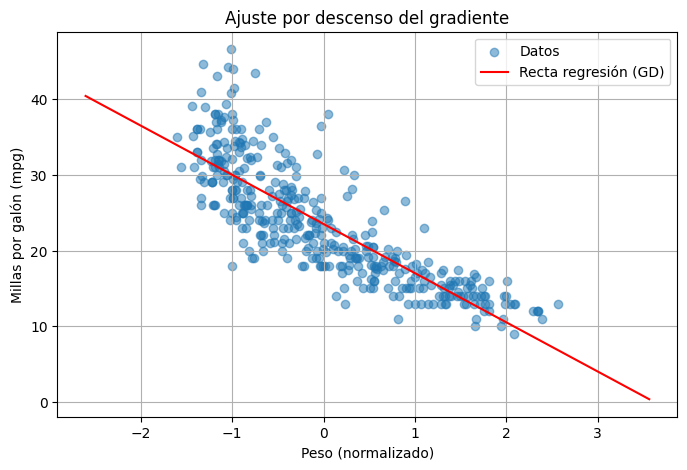

In [85]:
import numpy as np
import matplotlib.pyplot as plt

# 1 lectura de  datos
X = auto_mpg.data.features
y = auto_mpg.data.targets

X_np = X['weight'].to_numpy().reshape((X.shape[0], 1))
y_np = y.to_numpy().reshape((-1, 1))  

# 2. Escalado de X
X_gd = (X_np - X_np.mean()) / X_np.std()
y_gd = y_np

# 3. Añadiendo columna de unos
X_gd_ones = np.hstack([np.ones_like(X_gd), X_gd])

np.random.seed(0)
w0 = np.random.rand(2, 1)
eta = 0.01
iteraciones = 3000

#Aplicando el algoritmo de descenso del gradiente 
weights, loss = gradient_descent(X_gd_ones, y_gd, w0, iteraciones, eta)

# Dibuja la gráfica
x_max = np.max(X_gd) + 1
x_min = np.min(X_gd) - 1
x_vals = np.linspace(x_min, x_max, 100).reshape((-1, 1))
x_vals_ones = np.hstack([np.ones_like(x_vals), x_vals])

# Prediccion con los pesos finales
y_pred_vals = x_vals_ones @ weights[-1]

# Graficando
plt.figure(figsize=(8, 5))
plt.scatter(X_gd, y_gd, alpha=0.5, label="Datos")
plt.plot(x_vals, y_pred_vals, color='red', label="Recta regresión (GD)")
plt.xlabel("Peso (normalizado)")
plt.ylabel("Millas por galón (mpg)")
plt.title("Ajuste por descenso del gradiente")
plt.legend()
plt.grid(True)
plt.show()
